# 3.4.2 线性化能够走多远

## 学习目标与先修知识

能围绕平衡（equilibrium）推进偏差模型（model），比较近远扰动的轨迹（trajectory）误差与向量场（vector field）余项，用步长细化区分局部模型误差和离散误差，并限定局部稳定结论。

先修：上一节 雅可比矩阵（Jacobian matrix） 与 Taylor 近似；模态（mode）与第 2.4 章数值误差（numerical error）。 [复习上一节](01-偏导梯度与局部变化.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

在同一平衡附近增添 0.2 U 和 3 U，能否都用一张固定矩阵（matrix）预测后续过程？曲线间差异是线性化（linearization）导致，还是模拟步长导致？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
xstar=np.array([2.,4.]);J=np.array([[-.325,.1],[.2,-.1]])
for delta in [.2,3]:
    A1,A2=xstar+[delta,0]
    actual=np.array([.5-.2*A1+.1*A2-A1/(2+A1),.2*A1-.1*A2])
    print('增加',delta,'U；原变化率',actual,'；线性近似',J@[delta,0])

增加 0.2 U；原变化率 [-0.06380952  0.04      ] ；线性近似 [-0.065  0.04 ]
增加 3 U；原变化率 [-0.81428571  0.6       ] ；线性近似 [-0.975  0.6  ]


## 模型假设

同上一节的饱和清除模型，参数（parameter） a=.2/T、b=.1/T、u=.5 U/T、v=1 U/T、K=2 U。只改变初始第一室量，第二室保持 4 U。观察到 12 T，欧拉步长 .005 T，并用 .0025 T 复核。模型和参数用于教学，不是已校准的人体预测。

## 数学解释与推导

总变化率为 $u-g(A_1)$。u<v 时平衡满足 $A_1^*=uK/(v-u)$、$A_2^*=aA_1^*/b$；本例为 [2,4] U。u≥v 且 u>0 时，有限非负 A1 无法使 g=u，因此不能沿用这个平衡公式。b>0、K>0 也是当前推导的条件。

令偏差 $\delta=x-x^*$。因为 x* 不随时间变，$\dot\delta=f(x^*+\delta)\approx J(x^*)\delta$。若直接记录绝对状态（state） z，应写 $\dot z\approx J(x^*)(z-x^*)$，而不是 Jz。当前矩阵是
$$J^*=\begin{pmatrix}-.325&.1\\.2&-.1\end{pmatrix}/T.$$
它的迹是 −.425/T，行列式（determinant） .0125/T²。特征多项式为 $\lambda^2+.425\lambda+.0125$，两个根都负，所以线性偏差随时间衰减。对于光滑非线性系统，平衡内点的 J 所有特征值（eigenvalue）实部严格为负可推出**局部**渐近稳定（asymptotic stability）；若有零实部特征值，需进一步分析非线性项。

为何大扰动更不准？先保留物理单位。设第一室从平衡 $A_1^*$ 改变有量纲（dimension）的 $\Delta A$，第二室不变；$g(A_1)=vA_1/(K+A_1)$，原向量场减去一阶近似的精确余项为
$$R_1=\frac{vK(\Delta A)^2}{(K+A_1^*)^2(K+A_1^*+\Delta A)},\qquad R_2=0.$$
这里 $K+A_1^*+\Delta A>0$，余项的单位为 U/T。以 U、T 为数值单位，代入 $v=1\,\mathrm{U/T}$、$K=A_1^*=2\,\mathrm U$，并令 $\epsilon=\Delta A/(1\,\mathrm U)$。此时第一室的数值为 $2+\epsilon$，余项以 U/T 表示的数值式为
$$R_1(\epsilon)=\frac{\epsilon^2}{8(4+\epsilon)},\qquad R_2=0,$$
式中的 4 是 $K+A_1^*$ 以 U 表示的数值，ε 是扰动以 U 表示的数值；不是把无单位常数与有量纲的量直接相加。可把 g(2+ε) 与 g(2)+g′(2)ε 通分直接得到；因此小 ε 减半，余项约缩成四分之一。大扰动时局部斜率（slope）不再能代表整段函数。

轨迹误差还受到累计和局部反馈（feedback）影响，不能直接等同于某一点的 R。定义 $E=\max_{n,i}|x_{n,i}-z_{n,i}|$；另定义细化差 $D_h=\max_{n,i}|x_h(t_n)-x_{h/2}(t_n)|$。前者比较两个模型，后者比较同一模型的数值网格。分别检查两条轨迹的 D，确保它们足够小再解释 E。

用显式欧拉法（forward Euler method）同时更新两个分量，保留原始数值以检查非负性（nonnegativity）。固定观察时长，比较近远扰动下的轨迹误差，就能看到局部近似在哪些状态范围内较准确。

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def nonlinear_rate(state, a, b, u, v, K):
    first, second = state
    return [u-a*first+b*second-v*first/(K+first), a*first-b*second]

def jacobian(state, a, b, v, K):
    slope = v*K/(K+state[0])**2
    return [[-a-slope, b], [a, -b]]

def local_comparison(initial, a, b, u, v, K, h, steps):
    first_star = u*K/(v-u)
    equilibrium = [first_star, a*first_star/b]
    matrix = jacobian(equilibrium, a, b, v, K)
    original, linear = [list(initial)], [list(initial)]
    for _ in range(steps):
        rate = nonlinear_rate(original[-1], a, b, u, v, K)
        delta = [linear[-1][j]-equilibrium[j] for j in range(2)]
        linear_rate = [sum(row[j]*delta[j] for j in range(2)) for row in matrix]
        original.append([original[-1][j]+h*rate[j] for j in range(2)])
        linear.append([linear[-1][j]+h*linear_rate[j] for j in range(2)])
    error = max(abs(x-y) for pair, reference in zip(original, linear) for x, y in zip(pair, reference))
    return original, linear, error

## 对照实验

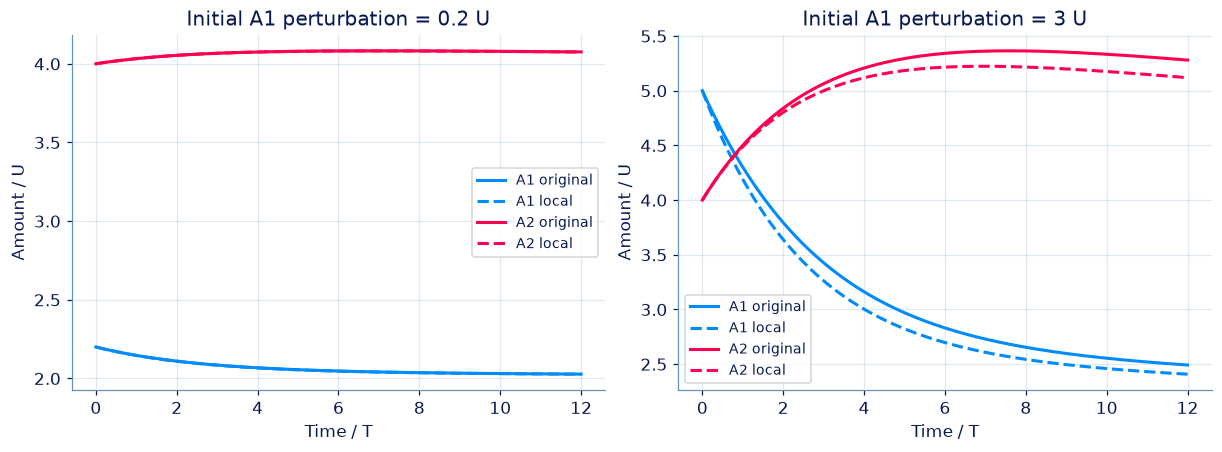

| 扰动 / U | 模型间最大差 / U | 原模型细化差 / U | 局部模型细化差 / U |
| --- | --- | --- | --- |
| 0.2 | 0.000990955 | 2.88925e-05 | 2.94865e-05 |
| 3 | 0.16482 | 0.00036311 | 0.000442297 |

In [4]:
h,end=.005,12
times=np.arange(round(end/h)+1)*h
fig,axes=plt.subplots(1,2,figsize=(11,4))
rows=[]
for ax,delta in zip(axes,[.2,3]):
    original,linear,error=local_comparison([2+delta,4],.2,.1,.5,1,2,h,round(end/h))
    original,linear=np.array(original),np.array(linear)
    fine,fine_linear,_=local_comparison([2+delta,4],.2,.1,.5,1,2,h/2,round(2*end/h))
    fine=np.array(fine)[::2];fine_linear=np.array(fine_linear)[::2]
    for i,color,label in [(0,BLUE,'A1'),(1,PINK,'A2')]:
        ax.plot(times,original[:,i],color=color,label=label+' original')
        ax.plot(times,linear[:,i],'--',color=color,label=label+' local')
    ax.set(xlabel='Time / T',ylabel='Amount / U',title=f'Initial A1 perturbation = {delta} U');ax.legend(fontsize=9)
    rows.append((delta,error,np.max(abs(original-fine)),np.max(abs(linear-fine_linear))))
plt.show()
display(Markdown(show_table(['扰动 / U','模型间最大差 / U','原模型细化差 / U','局部模型细化差 / U'],rows)))

## 结果解释

两幅图分别适应本组纵轴范围，不能按视觉缝隙直接比较绝对误差；表格使用相同 U 单位。颜色始终区分室，实虚线区分模型。远扰动的模型差更明显，步长细化差则小得多，支持将主要差异解释为局部近似的范围限制。

### 独立核对

用精确余项解释局部误差，用平衡保持检查坐标平移，再用网格细化判断数值误差是否足够小。

In [5]:
for delta,error,coarse,fine_error in rows:
    assert max(coarse,fine_error)<error*.05
assert rows[1][1]>rows[0][1]*20
exact,local,error=local_comparison([2,4],.2,.1,.5,1,2,.01,50)
np.testing.assert_allclose(exact,np.tile([2,4],(51,1)),atol=1e-12)
np.testing.assert_allclose(local,exact,atol=1e-12)
for epsilon in [.1,.05,.025]:
    f=np.array(nonlinear_rate([2+epsilon,4],.2,.1,.5,1,2))
    remainder=f-np.array(jacobian([2,4],.2,.1,1,2))@[epsilon,0]
    np.testing.assert_allclose(remainder,[epsilon**2/(8*(4+epsilon)),0],atol=1e-15)
assert np.all(np.linalg.eigvals(jacobian([2,4],.2,.1,1,2)).real<0)
print('平衡保持、独立余项、近远差异与数值细化检查通过。')

平衡保持、独立余项、近远差异与数值细化检查通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/03-04-多变量变化与局部线性化/explore/)：改变一个条件，观察时间曲线与状态空间（state space）中的运动，再回到本节解释。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：比较原模型与平衡附近的近似

沿用饱和清除两室模型（model） f1=u−aA1+bA2−vA1/(K+A1)，f2=aA1−bA2。u<v，平衡（equilibrium）为 x*=[uK/(v−u),a uK/(b(v−u))]。按同一步长分别推进原模型与局部线性模型。

**函数与代码模板**

```python
def solve(
    initial: list[float],
    a: float,
    b: float,
    u: float,
    v: float,
    K: float,
    h: float,
    steps: int,
) -> tuple[list[list[float]], list[list[float]], float]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `list[float]` | 两条轨迹（trajectory）共同的非负初始所追踪物质总量（tracked amount）。 | U |
| `a` | `float` | 室 1 到室 2 的交换系数。 | 1/T |
| `b` | `float` | 室 2 到室 1 的交换系数。 | 1/T |
| `u` | `float` | 进入室 1 的输入（input）速率。 | U/T |
| `v` | `float` | 室 1 饱和清除的最大速率。 | U/T |
| `K` | `float` | 清除速率达到 v/2 时的总量。 | U |
| `h` | `float` | 显式欧拉法（forward Euler method）步长。 | T |
| `steps` | `int` | 更新次数。 | 步 |

**返回值**

按以下顺序返回元组：(original, linear, error)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `original` | `list[list[float]]` | 原模型轨迹，含初值（initial condition）共 steps+1 行。 | U |
| `linear` | `list[list[float]]` | 局部近似轨迹，形状相同。 | U |
| `error` | `float` | 所有时刻、两个分量上绝对差的最大值。 | U |

**计算规则**

每步原模型 x←x+h*f(x)；局部模型 z←z+h*J(x*)*(z−x*)，J=[[-a−vK/(K+x1*)²,b],[a,−b]]。每条轨迹使用自己的段首状态（state）；不裁剪，不在每步重新选平衡。

**约束与边界**

- 所有数值有限；不修改输入列表。
- 0.1≤a,b≤0.5；0.1≤u≤0.5；1≤v,K≤2；initial 分量 0—10；0<h≤0.05；0≤steps≤400。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 两条轨迹（trajectory）共同的非负初始所追踪物质总量（tracked amount）。 | [2.2, 4] | U |
| a | 室 1 到室 2 的交换系数。 | 0.2 | 1/T |
| b | 室 2 到室 1 的交换系数。 | 0.1 | 1/T |
| u | 进入室 1 的输入（input）速率。 | 0.5 | U/T |
| v | 室 1 饱和清除的最大速率。 | 1 | U/T |
| K | 清除速率达到 v/2 时的总量。 | 2 | U |
| h | 显式欧拉法（forward Euler method）步长。 | 0.05 | T |
| steps | 更新次数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = [2.2, 4]
a = 0.2
b = 0.1
u = 0.5
v = 1
K = 2
h = 0.05
steps = 2

result = solve(initial, a, b, u, v, K, h, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| original | 原模型轨迹，含初值（initial condition）共 steps+1 行。 | [[2.2, 4], [2.1968095238095238, 4.002], [2.1936790527303702, 4.003958095238095]] | U |
| linear | 局部近似轨迹，形状相同。 | [[2.2, 4], [2.19675, 4.002], [2.1935628125, 4.003957499999999]] | U |
| error | 所有时刻、两个分量上绝对差的最大值。 | ≈ 0.0001162402 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[2.2, 4],
                    [2.1968095238095238, 4.002],
                    [2.1936790527303702,
                     4.003958095238095]],
                   [[2.2, 4],
                    [2.19675, 4.002],
                    [2.1935628125, 4.003957499999999]],
                   0.00011624023037004605)
```

**样例解释**

两条轨迹都从 [2.2,4] 开始。原模型首步第一分量约 2.19680952，局部模型为 2.19675；差异来自清除项曲率。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：比较原模型与平衡附近的近似](http://127.0.0.1:8000/chapters/03-04-%E5%A4%9A%E5%8F%98%E9%87%8F%E5%8F%98%E5%8C%96%E4%B8%8E%E5%B1%80%E9%83%A8%E7%BA%BF%E6%80%A7%E5%8C%96/practice/?question=p03-local-trajectories)

### 第 2 题 · 单项选择题：线性化究竟推进哪一个量

x*= [2,4] 是平衡（equilibrium），δ=x−x*。正确的局部模型（model）是哪一项？

- **A.** δ′=Jδ；若记录绝对状态（state）则 x′≈J(x−x*)。
- **B.** x′≈Jx，完全不必减平衡。
- **C.** δ′=Jx*。
- **D.** x(t)=x* 对所有初值（initial condition）都成立。

[作答：线性化究竟推进哪一个量](http://127.0.0.1:8000/chapters/03-04-%E5%A4%9A%E5%8F%98%E9%87%8F%E5%8F%98%E5%8C%96%E4%B8%8E%E5%B1%80%E9%83%A8%E7%BA%BF%E6%80%A7%E5%8C%96/practice/?question=p03-deviation-variable)

### 第 3 题 · 单项选择题：小扰动误差如何缩小

在平衡（equilibrium） [2,4] 周围只把 A1 增加 ε，v=1 U/T、K=2 U。饱和清除造成的向量场（vector field）一阶近似余项绝对值是 ε²/[8(4+ε)]（数值按 U、T）。ε 足够小时减半，余项约变成多少？

- **A.** 一半。
- **B.** 四分之一。
- **C.** 两倍。
- **D.** 始终为零。

[作答：小扰动误差如何缩小](http://127.0.0.1:8000/chapters/03-04-%E5%A4%9A%E5%8F%98%E9%87%8F%E5%8F%98%E5%8C%96%E4%B8%8E%E5%B1%80%E9%83%A8%E7%BA%BF%E6%80%A7%E5%8C%96/practice/?question=p03-local-error-order)

### 第 4 题 · 多项选择题：两条曲线接近是否足够

用很粗欧拉步长比较原模型（model）与线性化（linearization）。两条曲线很接近。哪些后续动作合理？

- **A.** 减半步长，分别检查每条轨迹（trajectory）是否稳定收敛。
- **B.** 直接宣布原系统全局线性。
- **C.** 比较近、远两组扰动，并保持其他条件不变。
- **D.** 把离散误差与模型线性化误差区分开。

[作答：两条曲线接近是否足够](http://127.0.0.1:8000/chapters/03-04-%E5%A4%9A%E5%8F%98%E9%87%8F%E5%8F%98%E5%8C%96%E4%B8%8E%E5%B1%80%E9%83%A8%E7%BA%BF%E6%80%A7%E5%8C%96/practice/?question=p03-model-numerical-error)

### 第 5 题 · 多项选择题：负特征值的结论到哪里为止

光滑非线性模型（model）在内点平衡（equilibrium）的 雅可比矩阵（Jacobian matrix） 所有特征值（eigenvalue）实部严格为负。哪些解释正确？

- **A.** 可推出该平衡的局部渐近稳定（local asymptotic stability）。
- **B.** 任何初值（initial condition）都一定回到该平衡。
- **C.** 有限几条模拟轨迹（trajectory）不能替代全局论证。
- **D.** 存在零实部特征值时，应继续分析高阶项而不直接套用此结论。

[作答：负特征值的结论到哪里为止](http://127.0.0.1:8000/chapters/03-04-%E5%A4%9A%E5%8F%98%E9%87%8F%E5%8F%98%E5%8C%96%E4%B8%8E%E5%B1%80%E9%83%A8%E7%BA%BF%E6%80%A7%E5%8C%96/practice/?question=p03-local-stability)

**进一步阅读**

[MIT 一阶系统课程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-iv-first-order-systems/)：矩阵方法、矩阵指数、相图与线性化。